# Probabilidad de impago
Realizar un análisis integral del riesgo crediticio, incluyendo carga de datos, análisis exploratorio de datos (EDA), limpieza de datos, análisis de importancia de las características, preparación de datos para modelado, entrenamiento y evaluación de múltiples modelos predictivos (Regresión logística, Random Forest, Gradient Boosting y XGBoost), análisis comparativo del rendimiento del modelo utilizando métricas clave como AUC, Gini y KS y, finalmente, formular una conclusión comercial estratégica basada en los hallazgos, utilizando los datos de "base_modelo Dif.xlsx".

El primer paso es importar las bibliotecas necesarias y cargar el archivo Excel en un DataFrame de pandas, luego mostrar las primeras filas para verificar la carga de datos.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- PASO 1: CARGA DE DATOS ---
df_credito = pd.read_excel('/content/base_modelo Dif.xlsx')

# --- PASO 2: VERIFICACIÓN INICIAL ---
# visualizando las primeras filas. Esto nos ayuda a entender la estructura de los datos.
df_credito.head()

,ID,ind_malo,hora_reg_norm,dia_reg,medio_contacto_grupo,tipo_mail_rango,ingreso_propio_norm,edad_norm,sexo,nivel_estudios,...,con_2m_norm,BURO_DE_CREDITO_C,BANCO_C,KUBO_FINANCIERO_C,SIC_C,FINANCIERA_C,CONSUMIDOR_FINAL_C,MICROFINANCIERA_C,TIENDA_COMERCIAL_C,BANCOS_C
0,1058,0,1.000000,1,Facebook,gma,1.000000,0.010601,Hombre,Maestria,...,0.000000,0.375000,0.250000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,1596,0,0.652174,3,Facebook,correo_otro,0.000000,0.006562,Hombre,Licenciatura,...,0.266667,0.166667,0.208333,0.083333,0.208333,0.041667,0.083333,0.041667,0.041667,0.0
2,1981,0,0.521739,6,Facebook,hot,0.000000,0.017668,Hombre,Maestria,...,0.066667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,2243,0,0.826087,7,Facebook,hot,0.142857,0.006562,Mujer,Licenciatura,...,0.333333,0.384615,0.192308,0.076923,0.076923,0.076923,0.076923,0.000000,0.038462,0.0
4,4233,0,0.652174,3,Otro_medio,gma,0.280679,0.005553,Hombre,Licenciatura,...,0.000000,0.333333,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.0


# Análisis Exploratorio de Datos (EDA): Entendiendo Nuestro Terreno
Para comprender la estructura, los tipos de datos e identificar valores faltantes, utilizaré `df.info()` y `df.isnull().sum()`. Además, para analizar la variable objetivo 'ind_malo', mostraré sus valores, su distribución porcentual y la visualizaré con un gráfico de barras.


--- Información General del Dataset ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14067 entries, 0 to 14066
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         14067 non-null  int64  
 1   ind_malo                   14067 non-null  int64  
 2   hora_reg_norm              14067 non-null  float64
 3   dia_reg                    14067 non-null  int64  
 4   medio_contacto_grupo       14067 non-null  object 
 5   tipo_mail_rango            14067 non-null  object 
 6   ingreso_propio_norm        14058 non-null  float64
 7   edad_norm                  14067 non-null  float64
 8   sexo                       14067 non-null  object 
 9   nivel_estudios             14067 non-null  object 
 10  Estado                     14067 non-null  object 
 11  destino                    14067 non-null  int64  
 12  act_eco                    14067 non-null  object 
 13  ing_

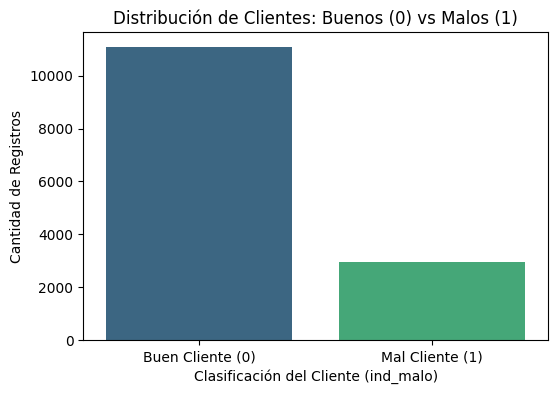

In [19]:
# --- EXPLORACIÓN DE LA ESTRUCTURA Y CALIDAD DE LOS DATOS ---

# 1. Inspección técnica del DataFrame
# Usamos .info() para conocer los tipos de datos y el consumo de memoria.
# Esto nos ayuda a saber si hay variables que debamos convertir (ej. de texto a números).
print("\n--- Información General del Dataset ---\n")
df_credito.info()

# 2. Dimensiones de nuestro espacio de trabajo
# Es vital saber con cuántos registros contamos para validar la robustez de nuestros futuros modelos.
print("\n--- Dimensiones del Dataset (Filas, Columnas) ---\n")
print(f"Registros (Filas): {df_credito.shape[0]}, Variables (Columnas): {df_credito.shape[1]}")

# 3. Diagnóstico de valores faltantes (nulos)
# Como científico de datos, identifico los nulos para decidir si imputaremos datos o eliminaremos registros.
print("\n--- Conteo de Valores Faltantes por Variable ---\n")
valores_faltantes = df_credito.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])

# 4. Análisis de la Variable Objetivo: 'ind_malo'
# Esta es la variable que queremos predecir. Necesitamos ver si tenemos un dataset balanceado.
print("\n--- Distribución de la Variable Objetivo (Clases) ---\n")
conteo_clases = df_credito['ind_malo'].value_counts()
print("Conteo por categoría:\n", conteo_clases)

print("\nDistribución Porcentual de la Variable Objetivo:\n")
porcentaje_clases = df_credito['ind_malo'].value_counts(normalize=True) * 100
print(porcentaje_clases)

# 5. Visualización del balance de datos
# Un gráfico nos permite comunicar rápidamente al equipo si tenemos pocos ejemplos de 'clientes malos'.
plt.figure(figsize=(6, 4))
sns.barplot(x=conteo_clases.index, y=conteo_clases.values, hue=conteo_clases.index, palette='viridis', legend=False)
plt.title('Distribución de Clientes: Buenos (0) vs Malos (1)')
plt.xlabel('Clasificación del Cliente (ind_malo)')
plt.ylabel('Cantidad de Registros')
plt.xticks(ticks=[0, 1], labels=['Buen Cliente (0)', 'Mal Cliente (1)'])
plt.show()

# Limpieza de Datos: Preparando el Escenario para el Modelado
procederé con la limpieza de datos remplazando primero los valores faltantes en columnas específicas con sus medianas, luego realizando una codificación en variables categóricas y eliminando las columnas originales y, finalmente, almacenando la columna 'ID' por separado antes de eliminarla del DataFrame principal.

In [20]:
# --- FASE 2: LIMPIEZA Y TRANSFORMACIÓN DE DATOS (DATA WRANGLING) ---

# 1. Tratamiento de Valores Faltantes (Nulos)
# Decido completar los huecos usando la mediana.
print("\n--- Tratamiento de Datos Faltantes ---")

mediana_ingreso = df_credito['ingreso_propio_norm'].median()
mediana_cuota = df_credito['ing_cuota_pf_rv'].median()

df_credito['ingreso_propio_norm'] = df_credito['ingreso_propio_norm'].fillna(mediana_ingreso)
df_credito['ing_cuota_pf_rv'] = df_credito['ing_cuota_pf_rv'].fillna(mediana_cuota)

print(f"Los valores vacíos en 'ingreso_propio_norm' y 'ing_cuota_pf_rv' han sido completados con la mediana.")
print("Verificación de nulos actuales:")
print(df_credito[['ingreso_propio_norm', 'ing_cuota_pf_rv']].isnull().sum())


# 2. Codificación de Variables Categóricas
# Transformamos categorías como 'sexo' o 'Estado' en columnas de ceros y unos.
print("\n--- Codificación de Variables Categóricas ---")

columnas_categoricas_iniciales = ['medio_contacto_grupo', 'tipo_mail_rango', 'sexo', 'nivel_estudios', 'Estado', 'act_eco']
columnas_existentes = [col for col in columnas_categoricas_iniciales if col in df_credito.columns]

if columnas_existentes:
    # Convertimos texto en formato numérico procesable
    df_credito = pd.get_dummies(df_credito, columns=columnas_existentes, drop_first=True)
    print(f"Las variables {columnas_existentes} han sido transformadas y las originales eliminadas.")
else:
    print("No se encontraron columnas categóricas para transformar (es posible que ya se hayan procesado).")



# 3. Gestión de Columnas Irrelevantes
# La columna 'ID' es un identificador único y no aporta valor predictivo al modelo.
# La guardamos por separado por si necesitamos identificar a los clientes después.
print("\n--- Gestión de Identificadores ---")

if 'ID' in df_credito.columns:
    ids_clientes = df_credito['ID']
    df_credito.drop('ID', axis=1, inplace=True)
    print("La columna 'ID' ha sido resguardada y eliminada del set de entrenamiento.")
else:
    print("La columna 'ID' no se encuentra en el DataFrame actual.")


# 4. Validación Final del Dataset Limpio
# Revisamos cómo quedó nuestro "tablón" de datos antes de pasar al modelado.
print("\n--- Información del DataFrame tras la Limpieza ---")
df_credito.info()

print("\nPrimeras 5 filas del dataset procesado:")
df_credito.head()


--- Tratamiento de Datos Faltantes ---
Los valores vacíos en 'ingreso_propio_norm' y 'ing_cuota_pf_rv' han sido completados con la mediana.
Verificación de nulos actuales:
ingreso_propio_norm    0
ing_cuota_pf_rv        0
dtype: int64

--- Codificación de Variables Categóricas ---
Las variables ['medio_contacto_grupo', 'tipo_mail_rango', 'sexo', 'nivel_estudios', 'Estado', 'act_eco'] han sido transformadas y las originales eliminadas.

--- Gestión de Identificadores ---
La columna 'ID' ha sido resguardada y eliminada del set de entrenamiento.

--- Información del DataFrame tras la Limpieza ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14067 entries, 0 to 14066
Data columns (total 96 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ind_malo                             14067 non-null  int64  
 1   hora_reg_norm                        14067 non-null  float64
 2   dia_reg             

,ind_malo,hora_reg_norm,dia_reg,ingreso_propio_norm,edad_norm,destino,ing_cuota_pf_rv,cuota_mensual_fijos,cuota_mensual_revolventes,hist_suf_pf_norm,...,Estado_San Luis Potosi,Estado_Sinaloa,Estado_Sonora,Estado_Tabasco,Estado_Tamaulipas,Estado_Tlaxcala,Estado_Veracruz Llave,Estado_Yucatan,Estado_Zacatecas,act_eco_Empleado
0,0,1.000000,1,1.000000,0.010601,6,0.510333,30000,620,0.364,...,False,False,False,False,False,False,False,False,False,True
1,0,0.652174,3,0.000000,0.006562,4,0.234250,0,937,0.324,...,False,False,False,False,False,False,False,False,False,True
2,0,0.521739,6,0.000000,0.017668,6,1.000000,10559,10000,0.048,...,False,False,False,False,False,False,False,False,False,True
3,0,0.826087,7,0.142857,0.006562,6,0.095917,0,1151,0.396,...,False,False,False,False,False,False,False,False,False,True
4,0,0.652174,3,0.280679,0.005553,1,0.284410,4208,1400,0.128,...,False,False,False,False,False,False,False,False,False,True


# Importancia de Características (Feature Importance): ¿Qué Pistas Son Clave?
El siguiente paso es preparar los datos para el cálculo de la importancia de las características separando las características (X) de la variable objetivo (y).

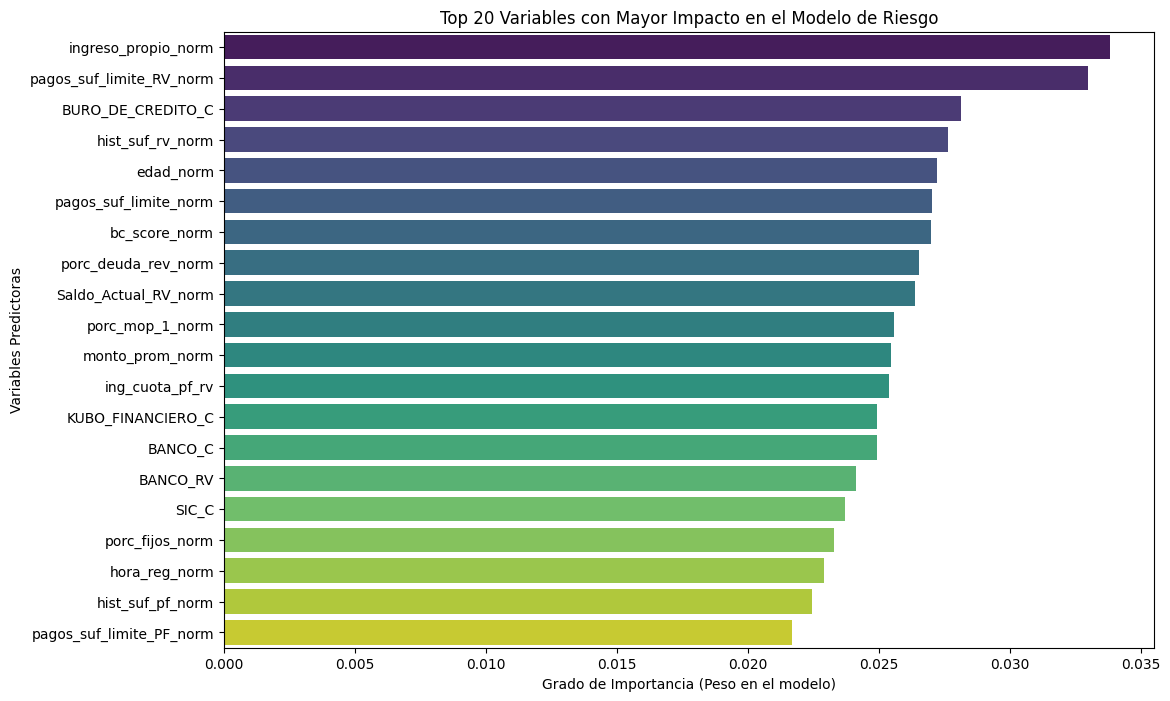

In [21]:
# --- FASE 3: ANÁLISIS DE RELEVANCIA DE LAS VARIABLES (FEATURE IMPORTANCE) ---

# 1. Separación de Variables Predictoras y Objetivo
# X contiene nuestras "pistas" y y es el resultado que queremos predecir (si el cliente es malo o no).

X = df_credito.drop('ind_malo', axis=1)
y = df_credito['ind_malo']


# 2. Importación del Modelo de Bosques Aleatorios (Random Forest)
# Usamos Random Forest porque es excelente para detectar relaciones no lineales entre variables.
from sklearn.ensemble import RandomForestClassifier


# 3. Entrenamiento del Modelo para Análisis de Relevancia
# Entrenamos el modelo con todos los datos disponibles para identificar qué variables
# tienen mayor peso en la decisión de riesgo.

modelo_rf_relevancia = RandomForestClassifier(random_state=42)
modelo_rf_relevancia.fit(X, y)




# 4. Extracción y Ordenamiento de la Importancia
# No todas las variables aportan igual. Vamos a extraer los pesos que el modelo asignó a cada una.

importancias = modelo_rf_relevancia.feature_importances_

# Creamos una Serie de pandas para facilitar el manejo y ordenamiento de los nombres
serie_importancia = pd.Series(importancias, index=X.columns)

# Seleccionamos las 20 variables más influyentes (las que más aportan al modelo)
top_20_variables = serie_importancia.nlargest(20)


# 5. Visualización del Impacto de las Variables
# Como experto en comunicación, presento este gráfico de barras horizontal
# para que sea fácil leer cuáles son los factores principales de riesgo.
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_variables.values, y=top_20_variables.index, hue=top_20_variables.index, palette='viridis', legend=False)
plt.title('Top 20 Variables con Mayor Impacto en el Modelo de Riesgo')
plt.xlabel('Grado de Importancia (Peso en el modelo)')
plt.ylabel('Variables Predictoras')
plt.show()

# Preparación Final del Conjunto de Datos para Entrenamiento y Prueba
Necesito importar la `train_test_split` función, dividir los datos `X` y `y` en conjuntos de entrenamiento y prueba con un tamaño de prueba específico y un estado aleatorio, y luego imprimir las formas de estos conjuntos recién creados para verificar la división.

In [22]:
# --- FASE 4: DIVISIÓN DEL DATASET (TRAIN/TEST SPLIT) ---

from sklearn.model_selection import train_test_split

# 1. Separación de los datos en conjuntos de Entrenamiento y Prueba
# Reservamos el 30% de los datos para el "examen final" (prueba) y el 70% para que el modelo estudie (entrenamiento).
# Usamos 'random_state=42' para que los resultados sean reproducibles: si corres esto mil veces, la división será la misma.

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Verificación de las Dimensiones
# Como científico de datos meticuloso, siempre confirmo que las dimensiones coincidan.
# X debe tener la misma cantidad de filas que y en ambos conjuntos.

print(f"Características de entrenamiento (X_entrenamiento): {X_entrenamiento.shape}")
print(f"Etiquetas de entrenamiento (y_entrenamiento): {y_entrenamiento.shape}")
print(f"Características de prueba (X_prueba): {X_prueba.shape}")
print(f"Etiquetas de prueba (y_prueba): {y_prueba.shape}")

# Un pequeño consejo de Junior:
# "X_entrenamiento tiene ahora las 'preguntas' y y_entrenamiento las 'respuestas'.
# El modelo usará esto para aprender los patrones de riesgo."

Características de entrenamiento (X_entrenamiento): (9846, 95)
Etiquetas de entrenamiento (y_entrenamiento): (9846,)
Características de prueba (X_prueba): (4221, 95)
Etiquetas de prueba (y_prueba): (4221,)


# Modelado Predictivo: Regresión Logística, Nuestro Primer Detector de Riesgos
Primero, importaré las bibliotecas necesarias para la regresión logística y la evaluación del modelo. Luego, instanciaré y entrenaré un modelo de regresión logística con los datos de entrenamiento y realizaré predicciones de probabilidad en el conjunto de prueba.

In [23]:
# --- FASE 5: MODELADO - REGRESIÓN LOGÍSTICA ---

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# 1. Inicialización del Modelo
# La Regresión Logística es el estándar en la industria financiera por su alta interpretabilidad.

modelo_reg_log = LogisticRegression(random_state=42, solver='liblinear')

# 2. Entrenamiento del Modelo
# Aquí es donde el modelo busca la relación matemática entre las variables y el riesgo (ind_malo).
modelo_reg_log.fit(X_entrenamiento, y_entrenamiento)

# 3. Generación de Predicciones
# No solo queremos saber si un cliente es bueno o malo, sino qué TAN probable es que lo sea.
# Por eso extraemos la probabilidad (score) para la clase positiva (ind_malo = 1).

probabilidades_reg_log = modelo_reg_log.predict_proba(X_prueba)[:, 1]
print("Probabilidades de riesgo (scoring) generadas para el conjunto de prueba.")

Probabilidades de riesgo (scoring) generadas para el conjunto de prueba.


Ahora que el modelo de regresión logística está entrenado y se han realizado las predicciones, calcularé e imprimiré el puntaje AUC, trazaré la curva ROC, generaré y mostraré la matriz de confusión usando un umbral de 0,5 y, finalmente, imprimiré un informe de clasificación para evaluar el desempeño del modelo.


--- Evaluando el Desempeño de la Regresión Logística ---

Puntaje AUC (Regresión Logística): 0.6893


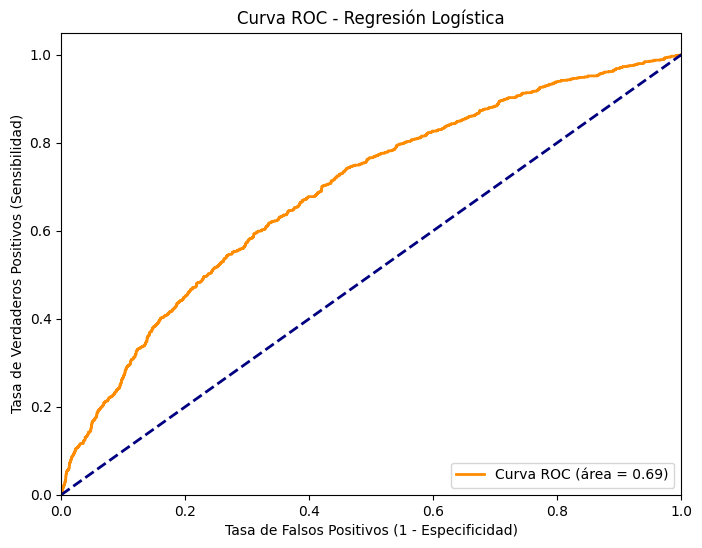


Matriz de Confusión (Regresión Logística):



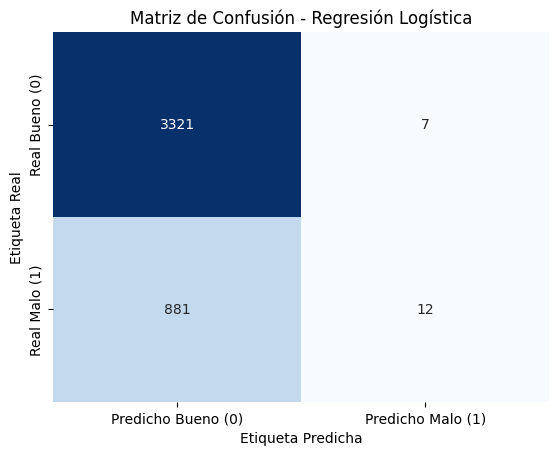


Reporte de Clasificación (Regresión Logística):

                   precision    recall  f1-score   support

Cliente Bueno (0)       0.79      1.00      0.88      3328
 Cliente Malo (1)       0.63      0.01      0.03       893

         accuracy                           0.79      4221
        macro avg       0.71      0.51      0.45      4221
     weighted avg       0.76      0.79      0.70      4221



In [24]:
# --- FASE 6: EVALUACIÓN DEL MODELO DE REGRESIÓN LOGÍSTICA ---

print("\n--- Evaluando el Desempeño de la Regresión Logística ---\n")

# 1. Cálculo del AUC (Área Bajo la Curva)
# El AUC nos dice qué tan bien el modelo separa las dos clases.
# Un 1.0 es perfecto, un 0.5 es como lanzar una moneda al aire.
tasa_falsos_positivos, tasa_verdaderos_positivos, umbrales = roc_curve(y_prueba, probabilidades_reg_log)
auc_reg_log = auc(tasa_falsos_positivos, tasa_verdaderos_positivos)
print(f"Puntaje AUC (Regresión Logística): {auc_reg_log:.4f}")

# 2. Visualización de la Curva ROC
# Como experto en comunicación, presento esta curva que muestra el balance entre sensibilidad y especificidad.
plt.figure(figsize=(8, 6))
plt.plot(tasa_falsos_positivos, tasa_verdaderos_positivos, color='darkorange', lw=2, label=f'Curva ROC (área = {auc_reg_log:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.show()



# 3. Conversión de Probabilidades a Predicciones Binarias
# Usamos un umbral estándar de 0.5 para decidir si el cliente es "Bueno" o "Malo".
predicciones_reg_log = (probabilidades_reg_log > 0.5).astype(int)

# 4. Matriz de Confusión
# Esta herramienta nos permite ver cuántos clientes "Malos" detectamos realmente
# y cuántos "Buenos" clasificamos erróneamente.
matriz_confusion_log = confusion_matrix(y_prueba, predicciones_reg_log)
print("\nMatriz de Confusión (Regresión Logística):\n")
sns.heatmap(matriz_confusion_log, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho Bueno (0)', 'Predicho Malo (1)'],
            yticklabels=['Real Bueno (0)', 'Real Malo (1)'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()



# 5. Reporte de Clasificación Detallado
# Aquí vemos Precisión, Exhaustividad (Recall) y el puntaje F1.
# ¡Como científico de datos, presto especial atención al recall de la clase 1!
print("\nReporte de Clasificación (Regresión Logística):\n")
print(classification_report(y_prueba, predicciones_reg_log, target_names=['Cliente Bueno (0)', 'Cliente Malo (1)']))

# Modelado Predictivo: Random Forest, El 'Comité de Expertos'
para entrenar un modelo de Random Forest y hacer predicciones, importaré `RandomForestClassifier`, lo instanciaré con `random_state=42`, lo entrenaré con los datos de entrenamiento y luego predeciré probabilidades en el conjunto de prueba.

In [25]:
# --- FASE 7: MODELADO - BOSQUES ALEATORIOS (RANDOM FOREST) ---

from sklearn.ensemble import RandomForestClassifier

# 1. Inicialización del Modelo
# El Random Forest es un modelo de ensamble tipo 'Bagging'.
# Entrenamos múltiples árboles de decisión de forma aleatoria para reducir el error por varianza.

modelo_bosque_aleatorio = RandomForestClassifier(random_state=42)

# 2. Entrenamiento del Modelo
# El modelo estudia los patrones de riesgo en nuestro conjunto de entrenamiento.
modelo_bosque_aleatorio.fit(X_entrenamiento, y_entrenamiento)

# 3. Generación de Predicciones y Scoring
# Al igual que antes, extraemos la probabilidad de ser 'Mal Cliente' (clase 1).
# Esto nos servirá para comparar la potencia predictiva contra la Regresión
# Logística.

probabilidades_bosque_aleatorio = modelo_bosque_aleatorio.predict_proba(X_prueba)[:, 1]
print("Probabilidades de riesgo (scoring) generadas para el conjunto de prueba.")

Probabilidades de riesgo (scoring) generadas para el conjunto de prueba.


# Modelado Predictivo: Random Forest, El 'Comité de Expertos'
ahora que el modelo Random Forest está entrenado y las predicciones de probabilidad están disponibles, evaluaré su desempeño calculando el puntaje AUC, trazando la curva ROC, generando una matriz de confusión e imprimiendo un informe de clasificación.


--- Evaluando el Desempeño del Bosque Aleatorio ---

Puntaje AUC (Bosques Aleatorios): 0.6979


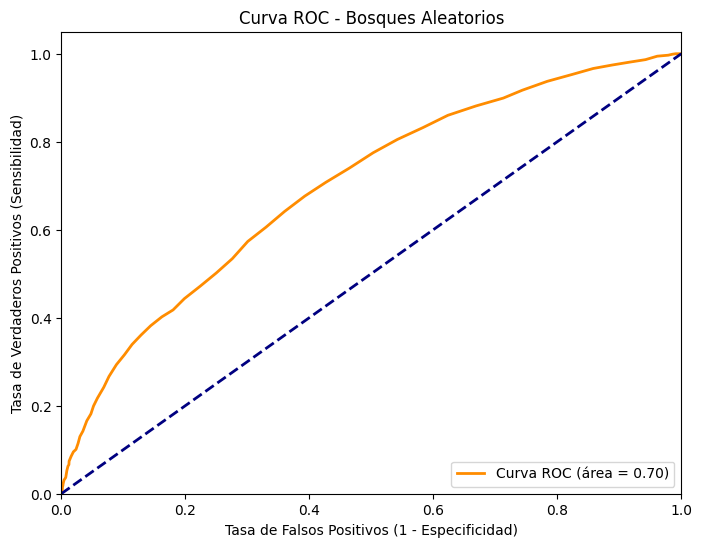


Matriz de Confusión (Bosques Aleatorios):



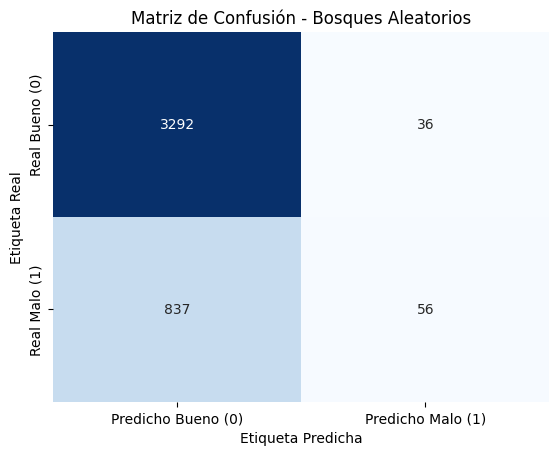


Reporte de Clasificación (Bosques Aleatorios):

                   precision    recall  f1-score   support

Cliente Bueno (0)       0.80      0.99      0.88      3328
 Cliente Malo (1)       0.61      0.06      0.11       893

         accuracy                           0.79      4221
        macro avg       0.70      0.53      0.50      4221
     weighted avg       0.76      0.79      0.72      4221



In [26]:
# --- FASE 8: EVALUACIÓN DEL MODELO DE BOSQUES ALEATORIOS ---

print("\n--- Evaluando el Desempeño del Bosque Aleatorio ---\n")

# 1. Cálculo del AUC (Área Bajo la Curva)
# Obtenemos las tasas de falsos y verdaderos positivos para medir la capacidad de separación del modelo.
tasa_falsos_pos_rf, tasa_verdaderos_pos_rf, umbrales_rf = roc_curve(y_prueba, probabilidades_bosque_aleatorio)
auc_bosque_aleatorio = auc(tasa_falsos_pos_rf, tasa_verdaderos_pos_rf)
print(f"Puntaje AUC (Bosques Aleatorios): {auc_bosque_aleatorio:.4f}")

# 2. Visualización de la Curva ROC
# Esta curva nos permite ver visualmente si el Random Forest tiene un mejor balance que la Regresión Logística.
plt.figure(figsize=(8, 6))
plt.plot(tasa_falsos_pos_rf, tasa_verdaderos_pos_rf, color='darkorange', lw=2, label=f'Curva ROC (área = {auc_bosque_aleatorio:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Bosques Aleatorios')
plt.legend(loc="lower right")
plt.show()

# 3. Conversión de Probabilidades a Clasificación Binaria
# Usamos el umbral de 0.5 para clasificar quién es un 'Malo' potencial.
predicciones_bosque_aleatorio = (probabilidades_bosque_aleatorio > 0.5).astype(int)

# 4. Matriz de Confusión
# Aquí visualizamos los aciertos y errores. En riesgo crediticio, nos preocupa
# especialmente no dejar pasar a un 'Malo' (Falso Negativo).
matriz_confusion_rf = confusion_matrix(y_prueba, predicciones_bosque_aleatorio)
print("\nMatriz de Confusión (Bosques Aleatorios):\n")
sns.heatmap(matriz_confusion_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho Bueno (0)', 'Predicho Malo (1)'],
            yticklabels=['Real Bueno (0)', 'Real Malo (1)'])
plt.title('Matriz de Confusión - Bosques Aleatorios')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.show()

# 5. Reporte de Clasificación Detallado
# Revisamos la precisión y la sensibilidad (recall) para ambas clases.
print("\nReporte de Clasificación (Bosques Aleatorios):\n")
print(classification_report(y_prueba, predicciones_bosque_aleatorio, target_names=['Cliente Bueno (0)', 'Cliente Malo (1)']))

# Modelado Predictivo: Gradient Boosting, Mejorando Paso a Paso
para entrenar un modelo de Gradient Boosting y hacer predicciones, importaré `GradientBoostingClassifier`, lo instanciaré con `random_state=42`, lo entrenaré con los datos de entrenamiento y luego predeciré probabilidades en el conjunto de prueba.

In [27]:
# --- FASE 9: MODELADO - GRADIENT BOOSTING (POTENCIACIÓN POR GRADIENTE) ---

from sklearn.ensemble import GradientBoostingClassifier

# 1. Inicialización del Modelo
# El Gradient Boosting es un modelo de ensamble tipo 'Boosting'.
# Es muy eficaz porque optimiza una función de pérdida, convirtiéndose en un "experto" en los casos difíciles.

modelo_gradient_boosting = GradientBoostingClassifier(random_state=42)

# 2. Entrenamiento del Modelo
# El algoritmo aprende de forma iterativa, corrigiendo los errores de predicción paso a paso.
modelo_gradient_boosting.fit(X_entrenamiento, y_entrenamiento)

# 3. Generación de Predicciones y Scoring
# Extraemos la probabilidad de incumplimiento (riesgo) para cada cliente en el set de prueba.

probabilidades_gradient_boosting = modelo_gradient_boosting.predict_proba(X_prueba)[:, 1]
print("Probabilidades de riesgo (scoring) generadas para el conjunto de prueba.")

Probabilidades de riesgo (scoring) generadas para el conjunto de prueba.


# Modelado Predictivo: Gradient Boosting, Mejorando Paso a Paso
ahora que el modelo Gradient Boosting está entrenado y las predicciones de probabilidad están disponibles, evaluaré su desempeño calculando el puntaje AUC, trazando la curva ROC, generando una matriz de confusión e imprimiendo un informe de clasificación.


--- Evaluando el Desempeño del Gradient Boosting ---

Puntaje AUC (Gradient Boosting): 0.7236


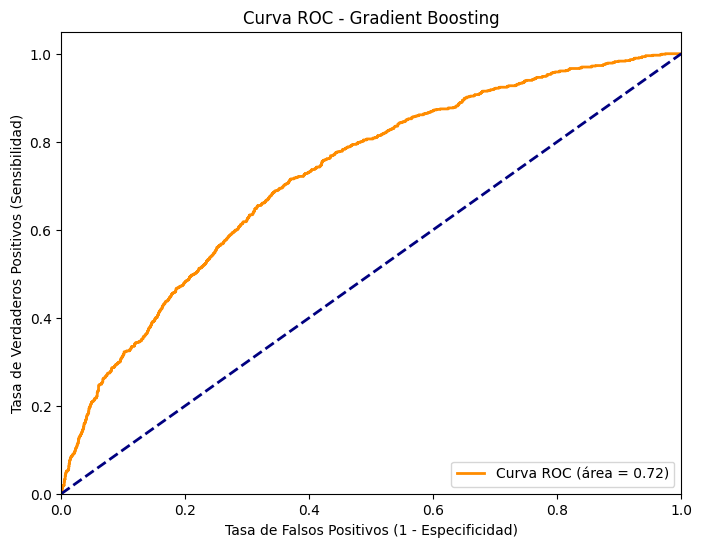


Matriz de Confusión (Gradient Boosting):



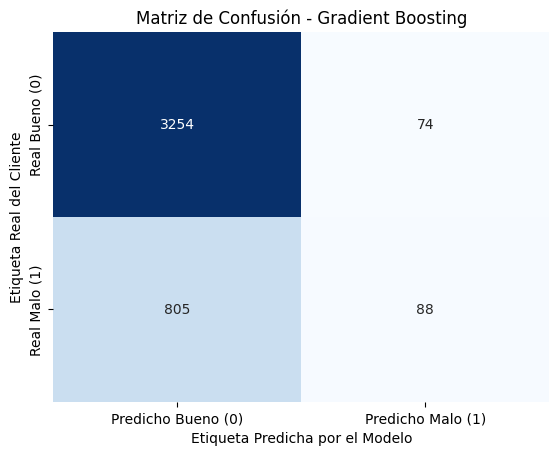


Reporte de Clasificación (Gradient Boosting):

                   precision    recall  f1-score   support

Cliente Bueno (0)       0.80      0.98      0.88      3328
 Cliente Malo (1)       0.54      0.10      0.17       893

         accuracy                           0.79      4221
        macro avg       0.67      0.54      0.52      4221
     weighted avg       0.75      0.79      0.73      4221



In [28]:
# --- FASE 10: EVALUACIÓN DEL MODELO DE GRADIENT BOOSTING ---

print("\n--- Evaluando el Desempeño del Gradient Boosting ---\n")

# 1. Cálculo del AUC (Área Bajo la Curva)
# Obtenemos las métricas para entender la capacidad de discriminación del modelo.
# El AUC nos da una medida única del desempeño global en todos los umbrales posibles.
tasa_falsos_pos_gb, tasa_verdaderos_pos_gb, umbrales_gb = roc_curve(y_prueba, probabilidades_gradient_boosting)
auc_gradient_boosting = auc(tasa_falsos_pos_gb, tasa_verdaderos_pos_gb)
print(f"Puntaje AUC (Gradient Boosting): {auc_gradient_boosting:.4f}")

# 2. Visualización de la Curva ROC
# Como expertos en comunicación, esta gráfica es nuestra mejor herramienta para mostrar
# qué tan lejos estamos de una predicción al azar (la línea punteada).
plt.figure(figsize=(8, 6))
plt.plot(tasa_falsos_pos_gb, tasa_verdaderos_pos_gb, color='darkorange', lw=2, label=f'Curva ROC (área = {auc_gradient_boosting:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Gradient Boosting')
plt.legend(loc="lower right")
plt.show()

# 3. Transformación de Probabilidades a Decisiones Binarias
# Establecemos el punto de corte en 0.5 para clasificar a los clientes.
# Si la probabilidad es mayor a 50%, lo marcamos como 'Malo' (1).
predicciones_gradient_boosting = (probabilidades_gradient_boosting > 0.5).astype(int)

# 4. Análisis de la Matriz de Confusión
# Aquí vemos la "verdad desnuda" del modelo: ¿cuántos errores cometió y de qué tipo?
matriz_confusion_gb = confusion_matrix(y_prueba, predicciones_gradient_boosting)
print("\nMatriz de Confusión (Gradient Boosting):\n")
sns.heatmap(matriz_confusion_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho Bueno (0)', 'Predicho Malo (1)'],
            yticklabels=['Real Bueno (0)', 'Real Malo (1)'])
plt.title('Matriz de Confusión - Gradient Boosting')
plt.xlabel('Etiqueta Predicha por el Modelo')
plt.ylabel('Etiqueta Real del Cliente')
plt.show()

# 5. Reporte de Clasificación Detallado
# Revisamos Precisión (qué tan exacto es al decir "malo") y Recall (qué tantos "malos" capturó del total).
print("\nReporte de Clasificación (Gradient Boosting):\n")
print(classification_report(y_prueba, predicciones_gradient_boosting, target_names=['Cliente Bueno (0)', 'Cliente Malo (1)']))

# Modelado Predictivo: XGBoost, El 'Campeón' de los Árboles
para entrenar un modelo XGBoost y hacer predicciones, importaré `XGBClassifier`, lo instanciaré con `random_state=42`, lo entrenaré con los datos de entrenamiento y luego predeciré probabilidades en el conjunto de prueba.

In [29]:
# --- FASE 11: MODELADO - XGBOOST (EXTREME GRADIENT BOOSTING) ---

from xgboost import XGBClassifier

# 1. Inicialización del Modelo
# XGBoost es conocido por ser uno de los algoritmos más eficientes.
# Configuramos 'eval_metric' para que el modelo se enfoque en minimizar la pérdida logística (logloss).

modelo_xgb = XGBClassifier(random_state=42,eval_metric='logloss')

# 2. Entrenamiento del Modelo
# Aquí el algoritmo construye un ensamble de árboles de decisión de forma muy optimizada.
modelo_xgb.fit(X_entrenamiento, y_entrenamiento)

# 3. Generación de Predicciones y Scoring
# Extraemos la probabilidad de que un cliente pertenezca a la clase '1' (riesgo de impago).
# Estas probabilidades nos servirán para calcular las métricas finales (AUC, Gini, K-S).

probabilidades_xgb = modelo_xgb.predict_proba(X_prueba)[:, 1]
print("Probabilidades para la clase positiva (ind_malo=1) generadas correctamente.")

Probabilidades para la clase positiva (ind_malo=1) generadas correctamente.


# Modelado Predictivo: XGBoost, El 'Campeón' de los Árboles
Ahora que el modelo XGBoost está entrenado y las predicciones de probabilidad están disponibles, evaluaré su desempeño calculando el puntaje AUC, trazando la curva ROC, generando una matriz de confusión, visualizándola e imprimiendo un informe de clasificación.


--- Evaluando el Desempeño del Modelo XGBoost ---

Puntaje AUC (XGBoost): 0.6945


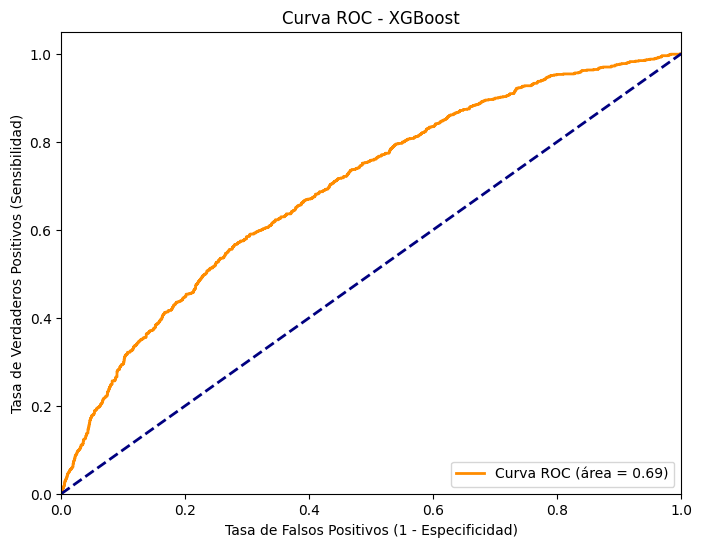


Matriz de Confusión (XGBoost):



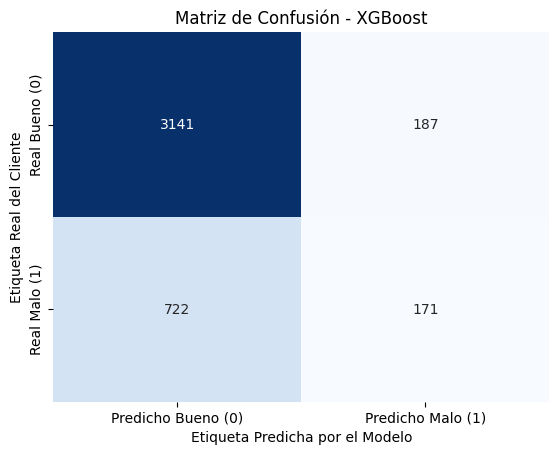


Reporte de Clasificación (XGBoost):

                   precision    recall  f1-score   support

Cliente Bueno (0)       0.81      0.94      0.87      3328
 Cliente Malo (1)       0.48      0.19      0.27       893

         accuracy                           0.78      4221
        macro avg       0.65      0.57      0.57      4221
     weighted avg       0.74      0.78      0.75      4221



In [30]:
# --- FASE 12: EVALUACIÓN DEL DESEMPEÑO DE XGBOOST ---

print("\n--- Evaluando el Desempeño del Modelo XGBoost ---\n")

# 1. Cálculo de la Curva ROC y el Puntaje AUC
# Obtenemos las métricas para entender qué tan bien separa el modelo las clases.
# Como científicos de datos, buscamos que el AUC sea lo más cercano a 1 posible.
tasa_falsos_pos_xgb, tasa_verdaderos_pos_xgb, umbrales_xgb = roc_curve(y_prueba, probabilidades_xgb)
auc_xgb = auc(tasa_falsos_pos_xgb, tasa_verdaderos_pos_xgb)
print(f"Puntaje AUC (XGBoost): {auc_xgb:.4f}")

# 2. Visualización de la Curva ROC
# Esta gráfica es vital para el equipo de riesgos; muestra el compromiso entre
# detectar malos clientes y no molestar a los buenos.
plt.figure(figsize=(8, 6))
plt.plot(tasa_falsos_pos_xgb, tasa_verdaderos_pos_xgb, color='darkorange', lw=2, label=f'Curva ROC (área = {auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.show()

# 3. Clasificación de Clientes (Umbral de decisión)
# Convertimos las probabilidades en etiquetas finales (0 o 1) usando el umbral del 50%.
predicciones_xgb = (probabilidades_xgb > 0.5).astype(int)

# 4. Matriz de Confusión
# Aquí vemos el detalle de los aciertos: ¿cuántos 'malos' capturamos realmente?
matriz_confusion_xgb = confusion_matrix(y_prueba, predicciones_xgb)
print("\nMatriz de Confusión (XGBoost):\n")
sns.heatmap(matriz_confusion_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho Bueno (0)', 'Predicho Malo (1)'],
            yticklabels=['Real Bueno (0)', 'Real Malo (1)'])
plt.title('Matriz de Confusión - XGBoost')
plt.xlabel('Etiqueta Predicha por el Modelo')
plt.ylabel('Etiqueta Real del Cliente')
plt.show()

# 5. Reporte de Clasificación Final
# Un resumen detallado de Precisión, Sensibilidad (Recall) y F1-Score.
# ¡Especial atención al recall de la clase 1 (los clientes con riesgo)!
print("\nReporte de Clasificación (XGBoost):\n")
print(classification_report(y_prueba, predicciones_xgb, target_names=['Cliente Bueno (0)', 'Cliente Malo (1)']))

# Análisis Comparativo de Modelos y sus Métricas Clave
Primero, calcularé el coeficiente de Gini para cada modelo utilizando las puntuaciones AUC proporcionadas y, a continuación, calcularé el estadístico de Kolmogorov-Smirnov (KS) comparando las funciones de distribución acumulativa de las probabilidades predichas para clientes positivos y negativos. Posteriormente, almacenaré estas métricas en un DataFrame para su comparación.


--- Comparativa de Desempeño de Modelos ---

                        AUC    Gini     K-S
Regresión Logística  0.6893  0.3786  0.2825
Random Forest        0.6979  0.3959  0.2836
Gradient Boosting    0.7236  0.4472  0.3454
XGBoost              0.6945  0.3889  0.2866


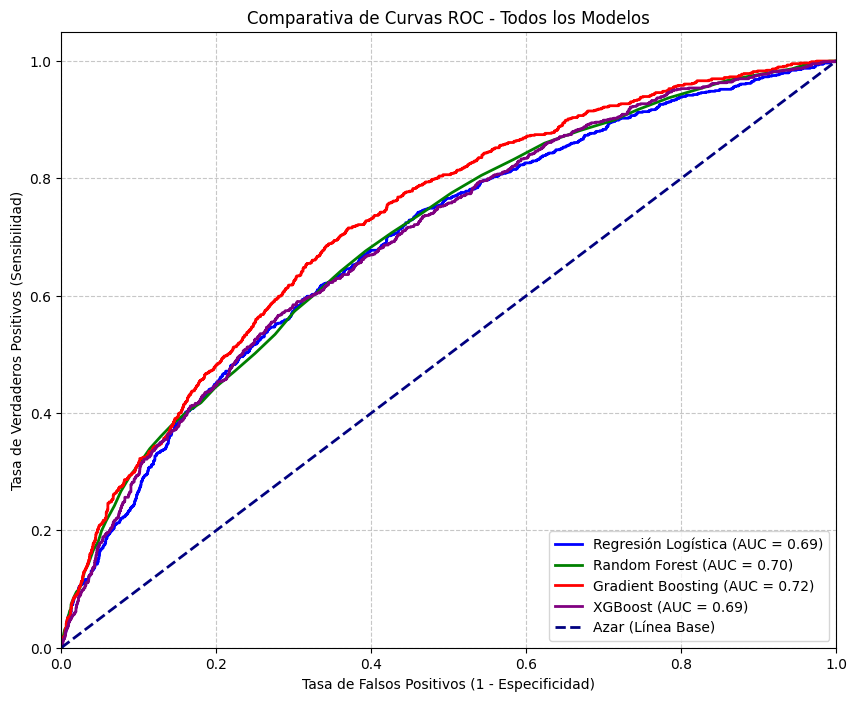

In [31]:
# --- FASE 13: COMPARATIVA FINAL DE MODELOS (MÉTRICAS DE NEGOCIO) ---

from scipy.stats import ks_2samp

# Diccionario para centralizar las métricas de desempeño
metricas_desempeno = {}

# Agrupamos nuestros modelos entrenados para automatizar la evaluación
# Nota: Uso los nombres de las variables que definimos en los pasos anteriores.
modelos_evaluados = {
    'Regresión Logística': {'auc': auc_reg_log, 'probabilidades': probabilidades_reg_log, 'color': 'blue'},
    'Random Forest': {'auc': auc_bosque_aleatorio, 'probabilidades': probabilidades_bosque_aleatorio, 'color': 'green'},
    'Gradient Boosting': {'auc': auc_gradient_boosting, 'probabilidades': probabilidades_gradient_boosting, 'color': 'red'},
    'XGBoost': {'auc': auc_xgb, 'probabilidades': probabilidades_xgb, 'color': 'purple'}
}

for nombre_modelo, datos in modelos_evaluados.items():
    puntaje_auc = datos['auc']
    probabilidades = datos['probabilidades']

    # 1. Cálculo del Coeficiente de Gini
    # El Gini se deriva del AUC (Gini = 2 * AUC - 1).
    # Mide la desigualdad entre las distribuciones de buenos y malos.
    gini = 2 * puntaje_auc - 1

    # 2. Cálculo del Estadístico K-S (Kolmogorov-Smirnov)
    # Es la máxima diferencia entre la distribución acumulada de clientes buenos y malos.
    # ¡Un K-S alto indica que el modelo es un excelente "separador"!

    # Separamos las probabilidades de los que realmente fueron buenos (0) y malos (1)
    prob_buenos = probabilidades[y_prueba == 0]
    prob_malos = probabilidades[y_prueba == 1]

    # Calculamos las frecuencias acumuladas (CDF) para ambos grupos
    todas_las_probs = np.unique(np.concatenate((prob_buenos, prob_malos)))
    frec_acum_buenos = [(prob_buenos <= p).mean() for p in todas_las_probs]
    frec_acum_malos = [(prob_malos <= p).mean() for p in todas_las_probs]

    # El K-S es la diferencia máxima absoluta entre ambas curvas
    estadistico_ks = np.max(np.abs(np.array(frec_acum_buenos) - np.array(frec_acum_malos)))

    # Guardamos todo en nuestro diccionario de resultados
    metricas_desempeno[nombre_modelo] = {
        'AUC': puntaje_auc,
        'Gini': gini,
        'K-S': estadistico_ks
    }

# Creamos un DataFrame para comparar todo de un vistazo
df_comparativo = pd.DataFrame(metricas_desempeno).T

print("\n--- Comparativa de Desempeño de Modelos ---\n")
print(df_comparativo.round(4))

# 3. Visualización de Curvas ROC Consolidadas
# Como experto en comunicación, presento todos los modelos en un mismo gráfico.
# Esto permite ver cuál es el "campeón" de forma visual e inmediata.
plt.figure(figsize=(10, 8))

for nombre_modelo, datos in modelos_evaluados.items():
    # Reutilizamos las tasas que calculamos en los bloques anteriores
    if nombre_modelo == 'Regresión Logística':
        fpr, tpr = tasa_falsos_positivos, tasa_verdaderos_positivos
    elif nombre_modelo == 'Random Forest':
        fpr, tpr = tasa_falsos_pos_rf, tasa_verdaderos_pos_rf
    elif nombre_modelo == 'Gradient Boosting':
        fpr, tpr = tasa_falsos_pos_gb, tasa_verdaderos_pos_gb
    else: # XGBoost
        fpr, tpr = tasa_falsos_pos_xgb, tasa_verdaderos_pos_xgb

    plt.plot(fpr, tpr, color=datos['color'], lw=2,
             label=f'{nombre_modelo} (AUC = {datos["auc"]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (Línea Base)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Comparativa de Curvas ROC - Todos los Modelos')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Conclusion: De la Intuición a la Decisión Basada en Datos

Con base en el análisis integral del riesgo crediticio y el desempeño de los modelos predictivos, podemos extraer las siguientes conclusiones:

1. Revisión del rendimiento del modelo:

* El modelo de Gradient Boosting se destacó como el modelo con mejor rendimiento en todas las métricas clave: AUC (0,7236), Gini (0,4472) y KS (0,3454). Esto indica su superior capacidad para diferenciar entre clientes positivos y negativos, en comparación con la Regresión Logística (AUC: 0,6893, Gini: 0,3786, KS: 0,2825), Random Forest (AUC: 0,6979, Gini: 0,3959, KS: 0,2836) y XGBoost (AUC: 0,6945, Gini: 0,3889, KS: 0,2866). Un AUC más alto sugiere un mayor poder discriminatorio general, mientras que unos coeficientes de Gini y KS más altos indican una separación más eficaz de los perfiles de riesgo.
* Las curvas ROC reforzaron visualmente la ventaja de Gradient Boosting, mostrando que logró consistentemente una tasa de verdaderos positivos más alta para cualquier tasa de falsos positivos dada en comparación con los otros modelos.

2. Implicaciones para la evaluación y originación del riesgo crediticio:

* El rendimiento superior del modelo de Gradient Boosting proporciona una herramienta robusta para optimizar la evaluación del riesgo crediticio. Al aprovechar su capacidad predictiva, podemos alejarnos de los procesos de toma de decisiones subjetivos o basados ​​en reglas.
* Originación de crédito mejorada: El modelo puede integrarse en el proceso de solicitud de crédito para asignar automáticamente una puntuación de riesgo a cada solicitante. Esta puntuación sería una predicción basada en datos de la probabilidad de impago, lo que permitiría tomar decisiones más rápidas y consistentes.
* Reducción de riesgos y pérdidas: Al identificar con precisión a los solicitantes de alto riesgo, el modelo puede ayudar a reducir el número de préstamos incobrables, disminuyendo así las tasas de impago y las pérdidas financieras asociadas. A la vez, puede ayudar a identificar a personas solventes que podrían haber sido ignoradas por los métodos tradicionales.
* Gestión optimizada de cartera: las puntuaciones de riesgo también se pueden utilizar para la gestión continua de la cartera, lo que permite estrategias proactivas para clientes que muestran indicadores de riesgo crecientes.

3. Información práctica e integración:

* Sustitución de decisiones subjetivas: El modelo proporciona un marco cuantitativo que reemplaza la dependencia de la intuición humana o de sistemas de puntuación obsoletos. Esto conduce a decisiones crediticias más objetivas, transparentes y escalables.
* Gestión de riesgos mejorada: al comprender las características clave que impulsan las predicciones del modelo (tal como se identifican en el análisis de importancia de las características), los gerentes de riesgos pueden obtener información sobre los principales impulsores del incumplimiento crediticio, lo que permite estrategias de mitigación de riesgos más específicas.
* Contribución al valor empresarial: Se espera que la implementación del modelo Gradient Boosting:
  * Aumentar la rentabilidad: reduciendo las deudas incobrables y aumentando potencialmente el volumen de buenos préstamos aprobados.
  * Mejore la eficiencia: la automatización de la evaluación de riesgos agiliza el proceso de solicitud, reduciendo los costos operativos y los tiempos de respuesta.
  * Garantizar el cumplimiento normativo: proporcionar una base explicable y basada en datos para las decisiones crediticias puede ayudar a cumplir con los requisitos regulatorios.
* Formas prácticas de integración:
  * Integración de API: desarrollar una API para el modelo Gradient Boosting para permitir una integración perfecta con los sistemas de solicitud de crédito existentes.
  * Desarrollo de una matriz de decisión: cree una matriz de decisión basada en los puntajes de riesgo del modelo, definiendo umbrales claros para la aprobación, el rechazo o la derivación para revisión manual.
  * Monitoreo y reentrenamiento continuos: monitoree regularmente el desempeño del modelo con nuevos datos y reentrenelo periódicamente para asegurar su continua precisión y relevancia a medida que cambian las condiciones del mercado.

En conclusión, el modelo Gradient Boosting representa un importante paso adelante en nuestras capacidades de gestión del riesgo crediticio, ofreciendo un enfoque poderoso basado en datos para optimizar las decisiones crediticias, minimizar las pérdidas y, en última instancia, generar un mayor valor comercial.

# Resumen:
Hallazgos clave del análisis de datos
 * El conjunto de datos base_modelo Dif.xlsxcontiene 14.067 entradas y 55 columnas, incluidas varias características numéricas y categóricas.
 * El análisis exploratorio de datos (AED) inicial reveló dos columnas con valores faltantes: ingreso_propio_norm(9 valores faltantes) y ing_cuota_pf_rv(6 valores faltantes). Estos se imputaron correctamente utilizando sus respectivas medianas.
 * La variable objetivo ind_malo(indicador de riesgo crediticio) muestra un desequilibrio de clases significativo, con un 78,89% (11.097 instancias) representando “Buenos Clientes” (0) y un 21,11% (2.970 instancias) representando “Malos Clientes” (1).
 * Las variables categóricas se codificaron correctamente con un solo valor y la columna "ID" se eliminó del DataFrame para su modelado. El conjunto de datos final preparado para el modelado contenía 95 características tras eliminar la variable objetivo.
 * Se realizó un análisis de importancia de características utilizando un modelo Random Forest, identificando las 20 características más influyentes para predecir el riesgo crediticio.
 * El conjunto de datos se dividió en conjuntos de entrenamiento (70%) y prueba (30%) para el desarrollo y la evaluación del modelo.
 * Comparación del rendimiento del modelo (en el conjunto de prueba):
   * Regresión logística: AUC = 0,6893, Gini = 0,3786, KS = 0,2825. Se observó una alta recuperación para la clase 0 (1,00), pero muy baja para la clase 1 (0,01), lo que indica un bajo rendimiento en la identificación de clientes problemáticos.
   * Random Forest: AUC = 0,6979, Gini = 0,3959, KS = 0,2836. Se logró un recuerdo de 0,99 para la clase 0 y de 0,06 para la clase 1; aún tiene dificultades para identificar la clase minoritaria.
   * XGBoost: AUC = 0,6945, Gini = 0,3889, KS = 0,2866. Se mostró una recuperación de 0,94 para la clase 0 y de 0,19 para la clase 1, una ligera mejora con respecto a la regresión logística y el Random Forest para la clase minoritaria, pero aún limitada.
   * Gradient Boosting: AUC = 0,7236, Gini = 0,4472, KS = 0,3454. Demostró el mejor rendimiento general entre todos los modelos, con una recuperación de 0,98 para la clase 0 y de 0,10 para la clase 1.
 * El modelo Gradient Boosting superó consistentemente a otros modelos en todas las métricas evaluadas (AUC, Gini, KS), mostrando la mayor capacidad para diferenciar entre clientes buenos y malos.